# Part 3: ResNet-18 Tile Order Hardness Analysis

This notebook reuses the Part 1 ResNet-18 baseline results and saved tile permutations to compute tile permutation hardness metrics without retraining.

In [12]:
from pathlib import Path
import importlib
import json
import os
import sys

In [13]:
current = Path.cwd().resolve()
for candidate in [current, *current.parents]:
    if (candidate / 'src').is_dir() and (candidate / 'requirements.txt').exists():
        ROOT = candidate
        break
else:
    ROOT = current

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

In [14]:
def install_project_requirements_for_colab(project_root: Path) -> None:
    """Install non-PyTorch dependencies in Colab without replacing CUDA-matched torch wheels."""
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError:
        return

    import subprocess

    requirements_path = project_root / 'requirements.txt'
    filtered_requirements = Path('/tmp/mlds_colab_requirements.txt')
    skip_prefixes = ('torch', 'torchvision')
    filtered_lines = [
        line
        for line in requirements_path.read_text().splitlines()
        if not line.strip().lower().startswith(skip_prefixes)
    ]
    filtered_requirements.write_text('\n'.join(filtered_lines) + '\n')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(filtered_requirements)])


In [15]:
install_project_requirements_for_colab(ROOT)

ROOT

PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

In [16]:

import matplotlib.pyplot as plt
import pandas as pd
from IPython.core.display import Image
from IPython.display import display
from PIL import Image as PILImage

import src.evaluation.tile_permutation_difficulty as tile_permutation_difficulty
import src.evaluation.experiment_results as experiment_results
from src.preprocessing.image_transforms import PILToFloatTensor, make_tile_compatible_image_size
from src.preprocessing.tile_permutations import tile_permutation_from_jsonable
from src.preprocessing.tile_transforms import apply_tile_permutation
import src.utils.config as config_module

config_module = importlib.reload(config_module)
tile_permutation_difficulty = importlib.reload(tile_permutation_difficulty)
experiment_results = importlib.reload(experiment_results)
compute_adjacency_destruction_hardness = tile_permutation_difficulty.compute_adjacency_destruction_hardness
compute_combined_hardness = tile_permutation_difficulty.compute_combined_hardness
compute_edge_continuity_disruption = tile_permutation_difficulty.compute_edge_continuity_disruption
compute_global_displacement = tile_permutation_difficulty.compute_global_displacement
Part3ExperimentConfig = config_module.Part3ExperimentConfig
load_part1_model_results = experiment_results.load_part1_model_results
load_part3_results = experiment_results.load_part3_results
load_or_build_part1_tile_permutations = experiment_results.load_or_build_part1_tile_permutations
part3_output_paths = experiment_results.part3_output_paths
load_experiment_samples = experiment_results.load_experiment_samples
run_part3_hardness_analysis = experiment_results.run_part3_hardness_analysis



## Configuration
Define Part 3 settings in `Part3ExperimentConfig`, reusing the Part 1 model/data/tile permutation outputs.


In [17]:

config = Part3ExperimentConfig()
results_dir = Path(config.results_dir)
figures_dir = Path(config.figures_dir)
part1_results_csv = results_dir / 'part1_raw_results.csv'
tile_permutation_csv = results_dir / 'part1_tile_permutations.csv'
output_paths = part3_output_paths(str(results_dir), str(figures_dir))

pd.DataFrame([
    {
        'part': config.part,
        'config_name': config.config_name,
        'model_name': config.model_name,
        'tiles_per_side_values': config.tiles_per_side_values,
        'num_tile_permutations': config.num_tile_permutations,
        'seed': config.seed,
        'weight_adj': config.weight_adj,
        'weight_edge': config.weight_edge,
        'weight_dist': config.weight_dist,
    }
])


,part,config_name,model_name,tiles_per_side_values,num_tile_permutations,seed,weight_adj,weight_edge,weight_dist
0,part3,part3_hardness_analysis,resnet18,"[1, 3]",2,42,0.5,0.3,0.2


In [18]:

METRIC_LABELS = {
    'global_tile_displacement': 'Global displacement',
    'adjacency_destruction_hardness': 'Adjacency destruction',
    'edge_continuity_disruption': 'Edge continuity disruption',
    'combined_hardness_score': 'Combined hardness',
}
METRIC_COLUMNS = list(METRIC_LABELS)


def display_part3_metrics_table(metrics: pd.DataFrame, max_rows: int = 12):
    table = metrics.copy()
    table['_reordered_first'] = ~((table['tiles_per_side'] == 1) | (table['tile_permutation_id'] == 0))
    table = table.sort_values(['_reordered_first', 'tiles_per_side', 'tile_permutation_id'], ascending=[False, True, True])
    table = table.drop(columns=['_reordered_first'])
    table = table.rename(columns=METRIC_LABELS | {
        'tiles_per_side': 'Grid',
        'num_tiles': 'Tiles',
        'tile_permutation_id': 'Tile Order',
        'tile_permutation_seed': 'Seed',
    })
    display(table.head(max_rows).style.format(precision=3))


def display_part3_joined_table(joined: pd.DataFrame, max_rows: int = 12):
    columns = ['tiles_per_side', 'num_tiles', 'tile_permutation_id', 'best_val_accuracy', *METRIC_COLUMNS]
    table = joined.loc[:, [column for column in columns if column in joined.columns]].copy()
    table['_reordered_first'] = ~((table['tiles_per_side'] == 1) | (table['tile_permutation_id'] == 0))
    table = table.sort_values(['_reordered_first', 'tiles_per_side', 'tile_permutation_id'], ascending=[False, True, True])
    table = table.drop(columns=['_reordered_first'])
    table = table.rename(columns=METRIC_LABELS | {
        'tiles_per_side': 'Grid',
        'num_tiles': 'Tiles',
        'tile_permutation_id': 'Tile Order',
        'best_val_accuracy': 'Best validation accuracy',
    })
    display(table.head(max_rows).style.format(precision=3))


def display_part3_correlations_table(correlations: pd.DataFrame):
    table = correlations.copy()
    table['metric'] = table['metric'].replace(METRIC_LABELS)
    table = table.rename(columns={
        'group': 'Group',
        'metric': 'Metric',
        'pearson': 'Pearson',
        'spearman': 'Spearman',
        'n': 'N',
    })
    display(table.style.format({'Pearson': '{:.3f}', 'Spearman': '{:.3f}'}))


def _deserialize_tile_permutation(raw_tile_permutation, tiles_per_side):
    if raw_tile_permutation is None:
        return None
    if isinstance(raw_tile_permutation, float) and pd.isna(raw_tile_permutation):
        return None
    if isinstance(raw_tile_permutation, str):
        raw_tile_permutation = json.loads(raw_tile_permutation)
    return tile_permutation_from_jsonable(raw_tile_permutation, tiles_per_side)


def _sorted_part3_tile_permutations(tile_permutation_csv: Path, config: Part3ExperimentConfig) -> pd.DataFrame:
    tile_permutations = load_or_build_part1_tile_permutations(
        tile_permutation_csv=str(tile_permutation_csv),
        tiles_per_side_values=config.tiles_per_side_values,
        num_tile_permutations=config.num_tile_permutations,
        seed=config.seed,
    ).copy()
    tile_permutations['_tiles_sort'] = tile_permutations['tiles_per_side'].fillna(0).astype(int)
    tile_permutations = tile_permutations.sort_values(['_tiles_sort', 'tile_permutation_id'])
    return tile_permutations.drop(columns=['_tiles_sort']).reset_index(drop=True)


def _load_example_tensor(image_path: Path, image_size: int, tiles_per_side: int):
    tile_compatible_size = make_tile_compatible_image_size(image_size, tiles_per_side)
    with PILImage.open(image_path) as image:
        resized = image.convert('RGB').resize(
            (tile_compatible_size, tile_compatible_size),
            PILImage.Resampling.BILINEAR,
        )
    return PILToFloatTensor()(resized)


def _tensor_to_image_array(image_tensor):
    return image_tensor.permute(1, 2, 0).clamp(0.0, 1.0).cpu().numpy()


def build_part3_example_image_metrics(
    validation_samples,
    tile_permutation_csv: Path,
    config: Part3ExperimentConfig,
) -> tuple[Path, pd.DataFrame]:
    if not validation_samples:
        raise ValueError('validation_samples must contain at least one image')

    image_path = Path(sorted(validation_samples, key=lambda sample: str(sample[0]))[0][0])
    rows = []
    for _, row in _sorted_part3_tile_permutations(tile_permutation_csv, config).iterrows():
        raw_tiles_per_side = row['tiles_per_side']
        tiles_per_side = None if pd.isna(raw_tiles_per_side) else int(raw_tiles_per_side)
        effective_tiles_per_side = 1 if tiles_per_side is None else tiles_per_side
        tile_permutation = _deserialize_tile_permutation(row['tile_permutation'], tiles_per_side)

        image_tensor = _load_example_tensor(image_path, config.image_size, effective_tiles_per_side)
        if tile_permutation is None:
            displayed_tensor = image_tensor
        else:
            displayed_tensor = apply_tile_permutation(image_tensor, tile_permutation)

        rows.append({
            'tiles_per_side': tiles_per_side,
            'grid': 'baseline' if tiles_per_side is None else f'{tiles_per_side}x{tiles_per_side}',
            'num_tiles': 1 if tiles_per_side is None else tiles_per_side * tiles_per_side,
            'tile_permutation_id': int(row['tile_permutation_id']),
            'image_array': _tensor_to_image_array(displayed_tensor),
            'global_tile_displacement': compute_global_displacement(tile_permutation, tiles_per_side),
            'adjacency_destruction_hardness': compute_adjacency_destruction_hardness(
                tile_permutation,
                tiles_per_side,
            ),
            'edge_continuity_disruption_raw': compute_edge_continuity_disruption(
                image_tensor,
                tile_permutation,
                tiles_per_side,
            ),
        })

    examples = pd.DataFrame(rows)
    raw_edge = examples['edge_continuity_disruption_raw'].astype(float)
    raw_min = float(raw_edge.min())
    raw_max = float(raw_edge.max())
    if raw_min == raw_max:
        examples['edge_continuity_disruption'] = 0.0
    else:
        examples['edge_continuity_disruption'] = (raw_edge - raw_min) / (raw_max - raw_min)

    examples['combined_hardness_score'] = [
        compute_combined_hardness(
            adjacency_destruction_hardness=float(row['adjacency_destruction_hardness']),
            edge_continuity_disruption=float(row['edge_continuity_disruption']),
            global_tile_displacement=float(row['global_tile_displacement']),
            weight_adj=config.weight_adj,
            weight_edge=config.weight_edge,
            weight_dist=config.weight_dist,
        )
        for _, row in examples.iterrows()
    ]
    return image_path, examples


def display_part3_example_image_metrics(image_path: Path, examples: pd.DataFrame):
    row_count = len(examples)
    fig, axes = plt.subplots(
        row_count,
        2,
        figsize=(9, max(2.1, 2.1 * row_count)),
        gridspec_kw={'width_ratios': [1.0, 1.35]},
        squeeze=False,
    )
    fig.suptitle(f'Deterministic validation image: {image_path.name}', y=0.995)
    for axis_row, (_, row) in zip(axes, examples.iterrows()):
        image_axis, text_axis = axis_row
        image_axis.imshow(row['image_array'])
        image_axis.set_title(f"Grid {row['grid']} | order {int(row['tile_permutation_id'])}")
        image_axis.axis('off')

        text_axis.axis('off')
        text_axis.text(
            0.0,
            0.5,
            '\n'.join([
                f"Adjacency destruction: {row['adjacency_destruction_hardness']:.3f}",
                f"Global displacement: {row['global_tile_displacement']:.3f}",
                f"Edge continuity: {row['edge_continuity_disruption']:.3f}",
                f"Combined hardness: {row['combined_hardness_score']:.3f}",
            ]),
            va='center',
            ha='left',
            fontsize=11,
        )
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

    table_columns = [
        'grid',
        'tile_permutation_id',
        'adjacency_destruction_hardness',
        'global_tile_displacement',
        'edge_continuity_disruption',
        'combined_hardness_score',
    ]
    display(examples[table_columns].style.format(precision=3))


## Data Loading
Load existing Part 1 results filtered to the configured Part 3 model.

In [19]:

part1_model_results = load_part1_model_results(str(part1_results_csv), config.model_name)
print(f'Part 1 {config.model_name} result rows: {len(part1_model_results)}')
display(
    part1_model_results[
        ['tiles_per_side', 'num_tiles', 'tile_permutation_id', 'best_val_accuracy']
    ].sort_values(['tiles_per_side', 'tile_permutation_id']).head(12).style.format(precision=3)
)


Part 1 resnet18 result rows: 3


,tiles_per_side,num_tiles,tile_permutation_id,best_val_accuracy
1,3.000,9,1,0.885
2,3.000,9,2,0.788
0,nan,1,0,0.865


## Compute Hardness Metrics
Compute tile permutation-only metrics, join them with ResNet-18 accuracy, and save outputs.

In [20]:

_, validation_samples, _ = load_experiment_samples(config, seed=config.seed)

analysis_results = run_part3_hardness_analysis(
    results_dir=str(results_dir),
    figures_dir=str(figures_dir),
    part1_results_csv=str(part1_results_csv),
    tile_permutation_csv=str(tile_permutation_csv),
    tiles_per_side_values=config.tiles_per_side_values,
    num_tile_permutations=config.num_tile_permutations,
    seed=config.seed,
    validation_samples=validation_samples,
    image_size=config.image_size,
    weight_adj=config.weight_adj,
    weight_edge=config.weight_edge,
    weight_dist=config.weight_dist,
    model_name=config.model_name,
    verbose=True,
    show_progress=True,
)

display_part3_metrics_table(analysis_results['metrics'])
display_part3_joined_table(analysis_results['joined'])


Preparing Part 3 output directories...
Loading or rebuilding Part 1 tile permutations...
Calculating hardness metrics...


Part 3 metrics: 100%|██████████| 3/3 [00:06<00:00,  2.04s/tile permutation]


Saving hardness metric table...
Loading Part 1 resnet18 results...
Joining hardness metrics with resnet18 accuracy...
Saving joined metric-accuracy table...
Computing metric-accuracy correlations...
Saving correlations and plots...
Part 3 hardness analysis complete.


,Grid,Tiles,Tile Order,Seed,Global displacement,Adjacency destruction,edge_continuity_disruption_raw,Edge continuity disruption,Combined hardness
1,3.000,9,1,42,0.833,0.833,45.817,0.850,0.838
2,3.000,9,2,42,0.583,1.000,53.917,1.000,0.917
0,nan,1,0,42,0.000,0.000,0.000,0.000,0.000


,Grid,Tiles,Tile Order,Best validation accuracy,Global displacement,Adjacency destruction,Edge continuity disruption,Combined hardness
1,3.000,9,1,0.885,0.833,0.833,0.850,0.838
2,3.000,9,2,0.788,0.583,1.000,1.000,0.917
0,nan,1,0,0.865,0.000,0.000,0.000,0.000


## Example Images and Image-Specific Scores
Display one deterministic validation image for each available tile permutation, with image-specific metric calculations.

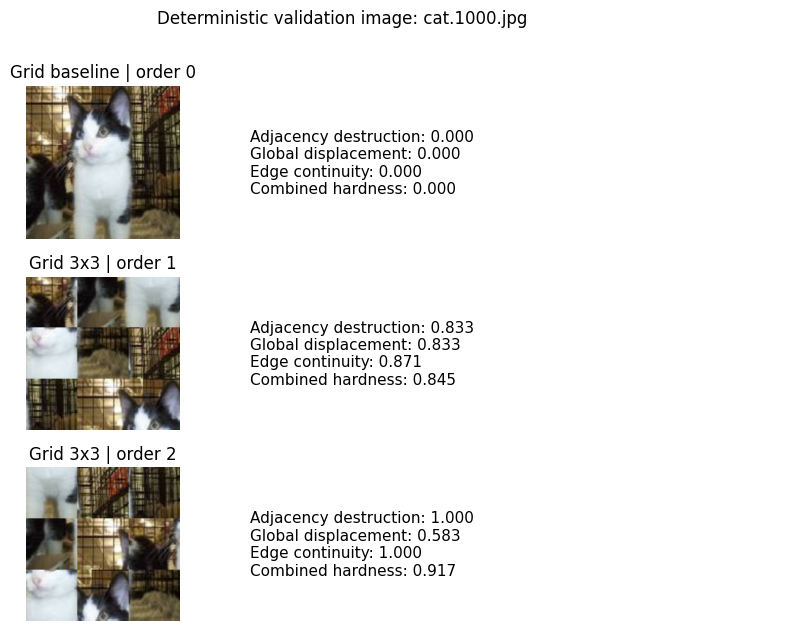

,grid,tile_permutation_id,adjacency_destruction_hardness,global_tile_displacement,edge_continuity_disruption,combined_hardness_score
0,baseline,0,0.000,0.000,0.000,0.000
1,3x3,1,0.833,0.833,0.871,0.845
2,3x3,2,1.000,0.583,1.000,0.917


In [21]:
example_image_path, example_image_metrics = build_part3_example_image_metrics(
    validation_samples=validation_samples,
    tile_permutation_csv=tile_permutation_csv,
    config=config,
)
display_part3_example_image_metrics(example_image_path, example_image_metrics)


## Correlations
Display Pearson and Spearman correlations between each hardness metric and the configured model validation accuracy.

In [22]:
saved_results = load_part3_results(str(results_dir))
display_part3_correlations_table(saved_results['correlations'])

if saved_results['correlations'][['pearson', 'spearman']].isna().any().any():
    print(
        'NaN means the correlation is undefined because the selected accuracy '
        'or metric values are constant in the joined Part 3 data.'
    )


,Group,Metric,Pearson,Spearman,N
0,resnet18,Global displacement,-0.037,0.500,3
1,resnet18,Adjacency destruction,-0.470,-0.500,3
2,resnet18,Edge continuity disruption,-0.456,-0.500,3
3,resnet18,Combined hardness,-0.399,-0.500,3


## Metric Plots
Display saved metric-vs-accuracy plots.

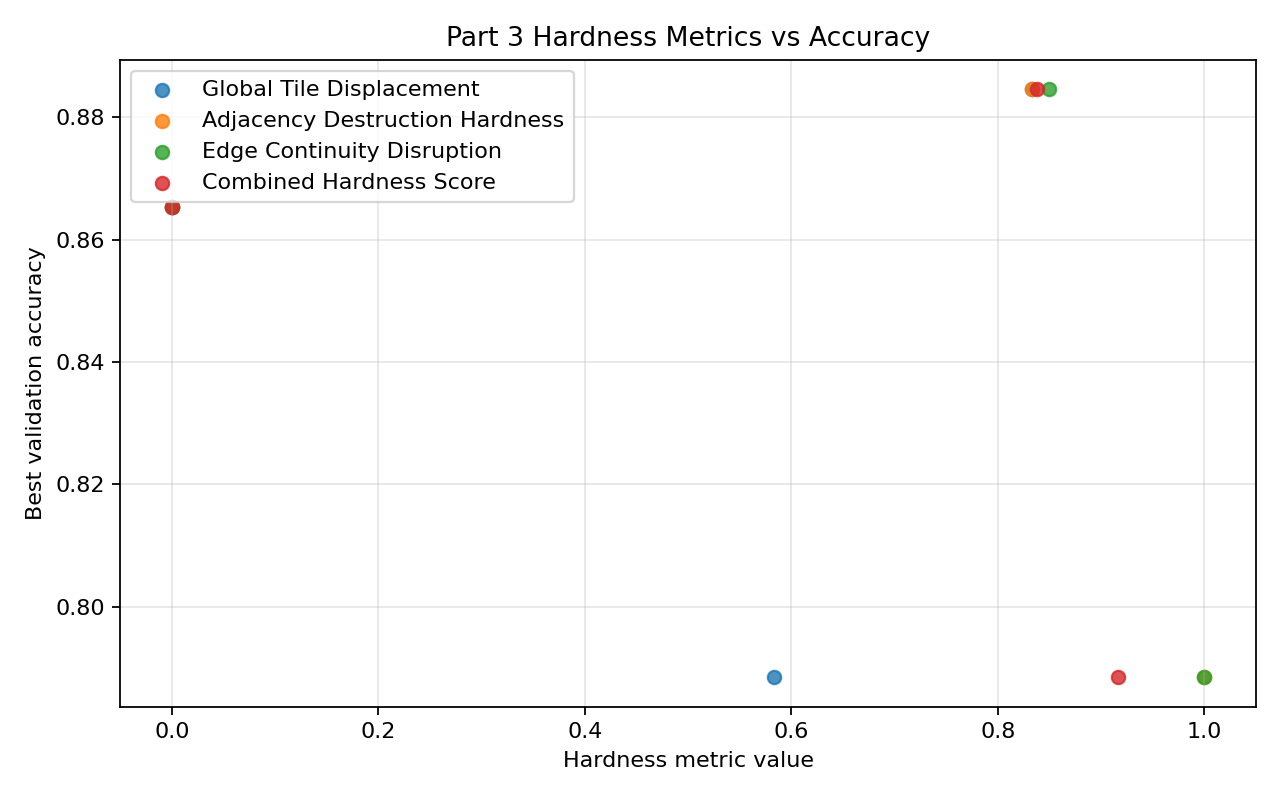

In [23]:
output_paths = part3_output_paths(str(results_dir), str(figures_dir))
for figure_path in output_paths['plots']:
    display(Image(filename=figure_path))
if not output_paths['plots']:
    print('No Part 3 plots found yet.')